# Breaking Data Symmetry is Needed For Generalization in Feature Learning Kernels

This notebooks reproduces some of the experiments from the paper.

In [1]:
import math
import pandas as pd
from math import ceil
import torch
import itertools
from itertools import product
import numpy as np
import scipy
import argparse
import random
import easydict
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)

In [2]:
from models import gaussian_kernel, quadratic_kernel

from agop_utils import calc_full_agops_exact, calc_full_agop, calc_batch_agop, _calc_full_agops, _calc_batch_agops, \
                       calc_full_agops_per_class, calc_batch_agops_per_class

from data import MULTIPLICATIVE_MODULO_OPERATIONS, ADDITIVE_MODULO_OPERATIONS, ALL_OPERATIONS, operation_mod_p_data, \
    make_data_splits, abelian_data, encode_abelian, decode_abelian, random_partition_generator, move_points_between_sets, \
    partition_fixed_points, is_multiple_reflections_case, move_reflected_pairs_to_test, degenerate_data_generator, decode_one_hot

from models import gaussian_kernel, quadratic_kernel

from train_kernel import get_test_kernel, solve, update, eval, rfm, train, get_reflection_M

from utils import print_one_hot_pairs, print_one_hot_pairs_abelian, split_predictions, theoretical_predictions, \
    compare_theory, plot_reflection_axis, plot_abelian_reflection_axis, plot_multiplicative_reflection_axis, plot_cyclic_diagonal, visualize_ab_grid

from group_utils import _r, _s, _apply_g, get_G_orbits, get_permutation_representation, permutation_representations

## Breaking data symmetry enables generalization

Experiments corresponding to Section 3 and Appendix D. 

In [17]:
data_args = easydict.EasyDict({
    "operation": 'x+y',
    "prime": 61,
    "partition_type": 'degenerate', # Degenerate data partition: 
    "reflections": 0,               # Train on all samples except the fixed points under reflection sr^k for k = 0
    "n_test_to_train": 0,
    "n_train_to_test": 0,
    "n_pairs_to_test": 0,
    "M_reflection": None
})

rfm_args = easydict.EasyDict({
    "iters": 60,
    "ridge": 0.0,
    "bandwidth": 2.5,
    "ntk_depth": 2,
    "kernel_type": 'gaussian',
    "print_progress": False,
    "device": torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
})

device = rfm_args.device
torch.set_num_threads(1)

RFM with a Gaussian kernel trained on all samples except the fixed points under reflection sr^0 = s for addition modulo 61 doesn't generalize (0% test accuracy). Moving one random sample from the train set to the test set yields a generalizing partition (RFM with a Gaussian kernel trained on this set gets 98% test accuracy). 

In [18]:
rfm_args.kernel_type = 'gaussian'
data_args.prime = 61
data_args.operation = 'x+y'

data_args.n_train_to_test = 0
results1, _ = train(data_args, rfm_args)

data_args.n_train_to_test = 1
results2, _ = train(data_args, rfm_args)

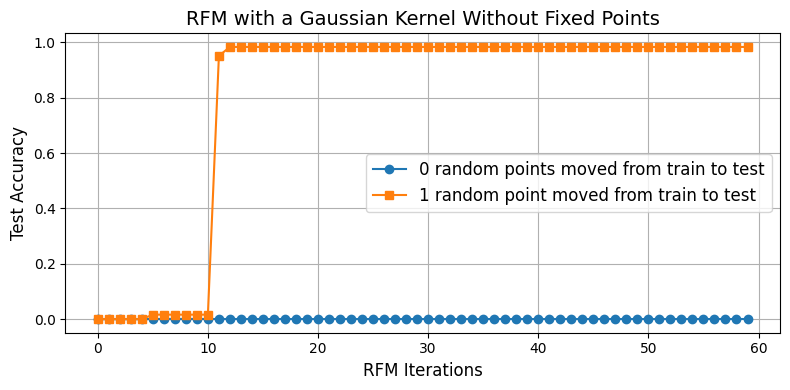

In [30]:
accs1 = [x.detach().cpu() for x in results1.test_accs]
accs2 = [x.detach().cpu() for x in results2.test_accs]

plt.figure(figsize=(8, 4))
plt.plot(accs1, label="0 random points moved from train to test", marker='o', linestyle='-')
plt.plot(accs2, label="1 random point moved from train to test", marker='s', linestyle='-')

plt.title("RFM with a Gaussian Kernel Without Fixed Points", fontsize=14)
plt.xlabel("RFM Iterations", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

RFM with a Quadratic kernel trained on all samples except the fixed points under reflection sr^0 = s for addition modulo 61 doesn't generalize (0% test accuracy). Moving 100 random samples from the train set to the test set improves accuracy (70% test accuracy), and removing more samples, like 200, improves accuracy more (80% test accuracy).

In [31]:
rfm_args.kernel_type = 'quadratic'
data_args.prime = 61
data_args.operation = 'x+y'

data_args.n_train_to_test = 0
results1, _ = train(data_args, rfm_args)

data_args.n_train_to_test = 100
results2, _ = train(data_args, rfm_args)

data_args.n_train_to_test = 200
results3, _ = train(data_args, rfm_args)

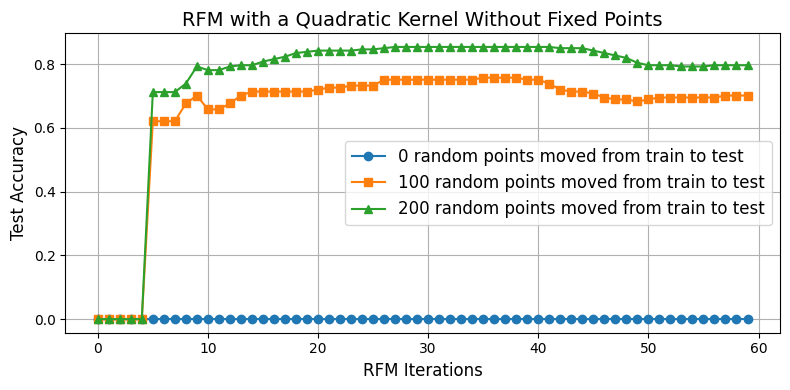

In [32]:
accs1 = [x.detach().cpu() for x in results1.test_accs]
accs2 = [x.detach().cpu() for x in results2.test_accs]
accs3 = [x.detach().cpu() for x in results3.test_accs]

plt.figure(figsize=(8, 4))
plt.plot(accs1, label="0 random points moved from train to test", marker='o', linestyle='-')
plt.plot(accs2, label="100 random points moved from train to test", marker='s', linestyle='-')
plt.plot(accs3, label="200 random points moved from train to test", marker='^', linestyle='-')

plt.title("RFM with a Quadratic Kernel Without Fixed Points", fontsize=14)
plt.xlabel("RFM Iterations", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Moving points by symmetric pairs under the reflection used to build the partition doesn't improve generalization. We test this for a Quadratic kernel on multiplication modulo 53 and reflection sr^13 and a Gaussian kernel on division modulo 47 and reflection sr^27.

In [38]:
rfm_args.kernel_type = 'quadratic'
data_args.prime = 53
data_args.operation = 'x*y'
data_args.reflections = 13
data_args.n_train_to_test = 0

te_acc = []
tr_acc = []
for i in [0, 1, 10, 20, 30, 40, 50]:
    data_args.n_pairs_to_test = i
    results, _ = train(data_args, rfm_args)
    te_acc.append(results.test_accs[-1].detach().cpu())
    tr_acc.append(results.train_accs[-1].detach().cpu())

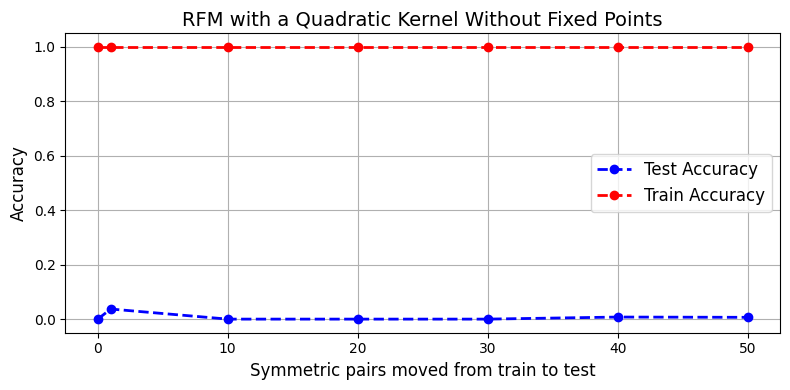

In [44]:
x = [0, 1, 10, 20, 30, 40, 50]
plt.figure(figsize=(8, 4))
plt.plot(x, te_acc, color='blue', label='Test Accuracy', marker='o', linewidth=2, linestyle='--')
plt.plot(x, tr_acc, color='red', label='Train Accuracy', marker='o', linewidth=2, linestyle='--')

plt.title("RFM with a Quadratic Kernel Without Fixed Points", fontsize=14)
plt.xlabel("Symmetric pairs moved from train to test", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
rfm_args.kernel_type = 'gaussian'
data_args.prime = 47
data_args.operation = 'x/y'
data_args.reflections = 27
data_args.n_train_to_test = 0

te_acc = []
tr_acc = []
for i in [0, 1, 10, 20, 30, 40, 50]:
    data_args.n_pairs_to_test = i
    results, _ = train(data_args, rfm_args)
    te_acc.append(results.test_accs[-1].detach().cpu())
    tr_acc.append(results.train_accs[-1].detach().cpu())

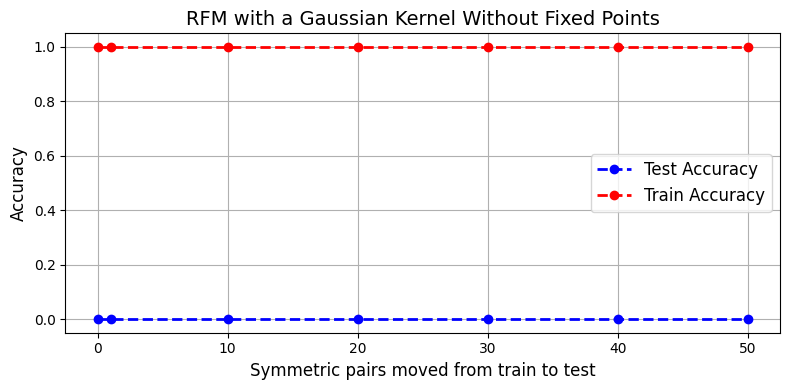

In [46]:
x = [0, 1, 10, 20, 30, 40, 50]
plt.figure(figsize=(8, 4))
plt.plot(x, te_acc, color='blue', label='Test Accuracy', marker='o', linewidth=2, linestyle='--')
plt.plot(x, tr_acc, color='red', label='Train Accuracy', marker='o', linewidth=2, linestyle='--')

plt.title("RFM with a Gaussian Kernel Without Fixed Points", fontsize=14)
plt.xlabel("Symmetric pairs moved from train to test", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature matrices and representation matrices

Experiments corresponding to Section 4 and Appendix E. 

We show the feature matrix (AGOP) learned by RFM with a Gaussian Kernel on division modulo 47 trained without the fixed points under reflection sr^27 after removing 50 symmetric pairs under the reflection.

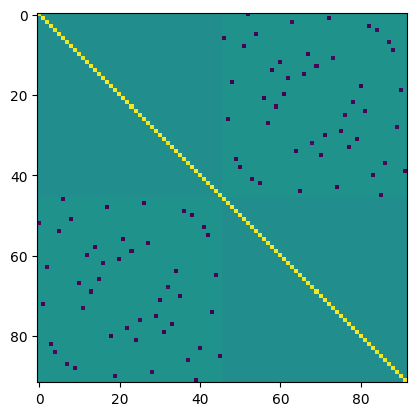

In [48]:
plt.imshow(results.M_list[-1].cpu())

We show the permutation matrix corresponding to the representation of the action sr^27 on division modulo 47.

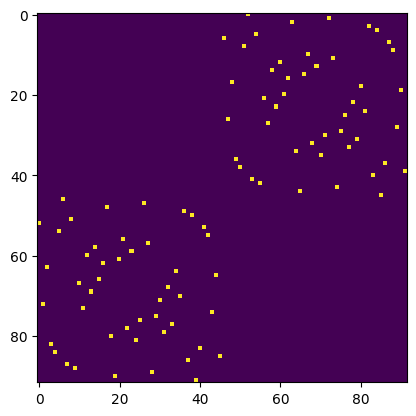

In [49]:
reps = permutation_representations(47, 'x/y')
plt.imshow(reps[('s',27)])

For the abelian group $\mathcal{A}\cong \mathbb{Z}_3 \times \mathbb{Z}_7$ we provide a full set of comparisons between the AGOPs learned by RFM with a Gaussian kernel trained on all data samples except for the fixed points under a reflection $sr^x$ for every $x \in \mathcal{A}$ and the permutation representation of such reflection.

In [59]:
data_args.operation = 'abelian'
data_args.prime = [3,7]
rfm_args.kernel_type = 'gaussian'
data_args.n_test_to_train = 0
data_args.n_train_to_test = 0
data_args.n_pairs_to_test = 0

agops = []
te_acc = []
tr_acc = []
refls = []
for k in list(itertools.product(*[range(pi) for pi in data_args.prime])):
    data_args.reflections = list(k)
    results, _ = train(data_args, rfm_args)
    agops.append(results.M_list[-1].cpu())
    te_acc.append(results.test_accs[-1].detach().cpu())
    tr_acc.append(results.train_accs[-1].detach().cpu())
    refls.append(list(k))

In [66]:
reps = permutation_representations([3,7], 'abelian')

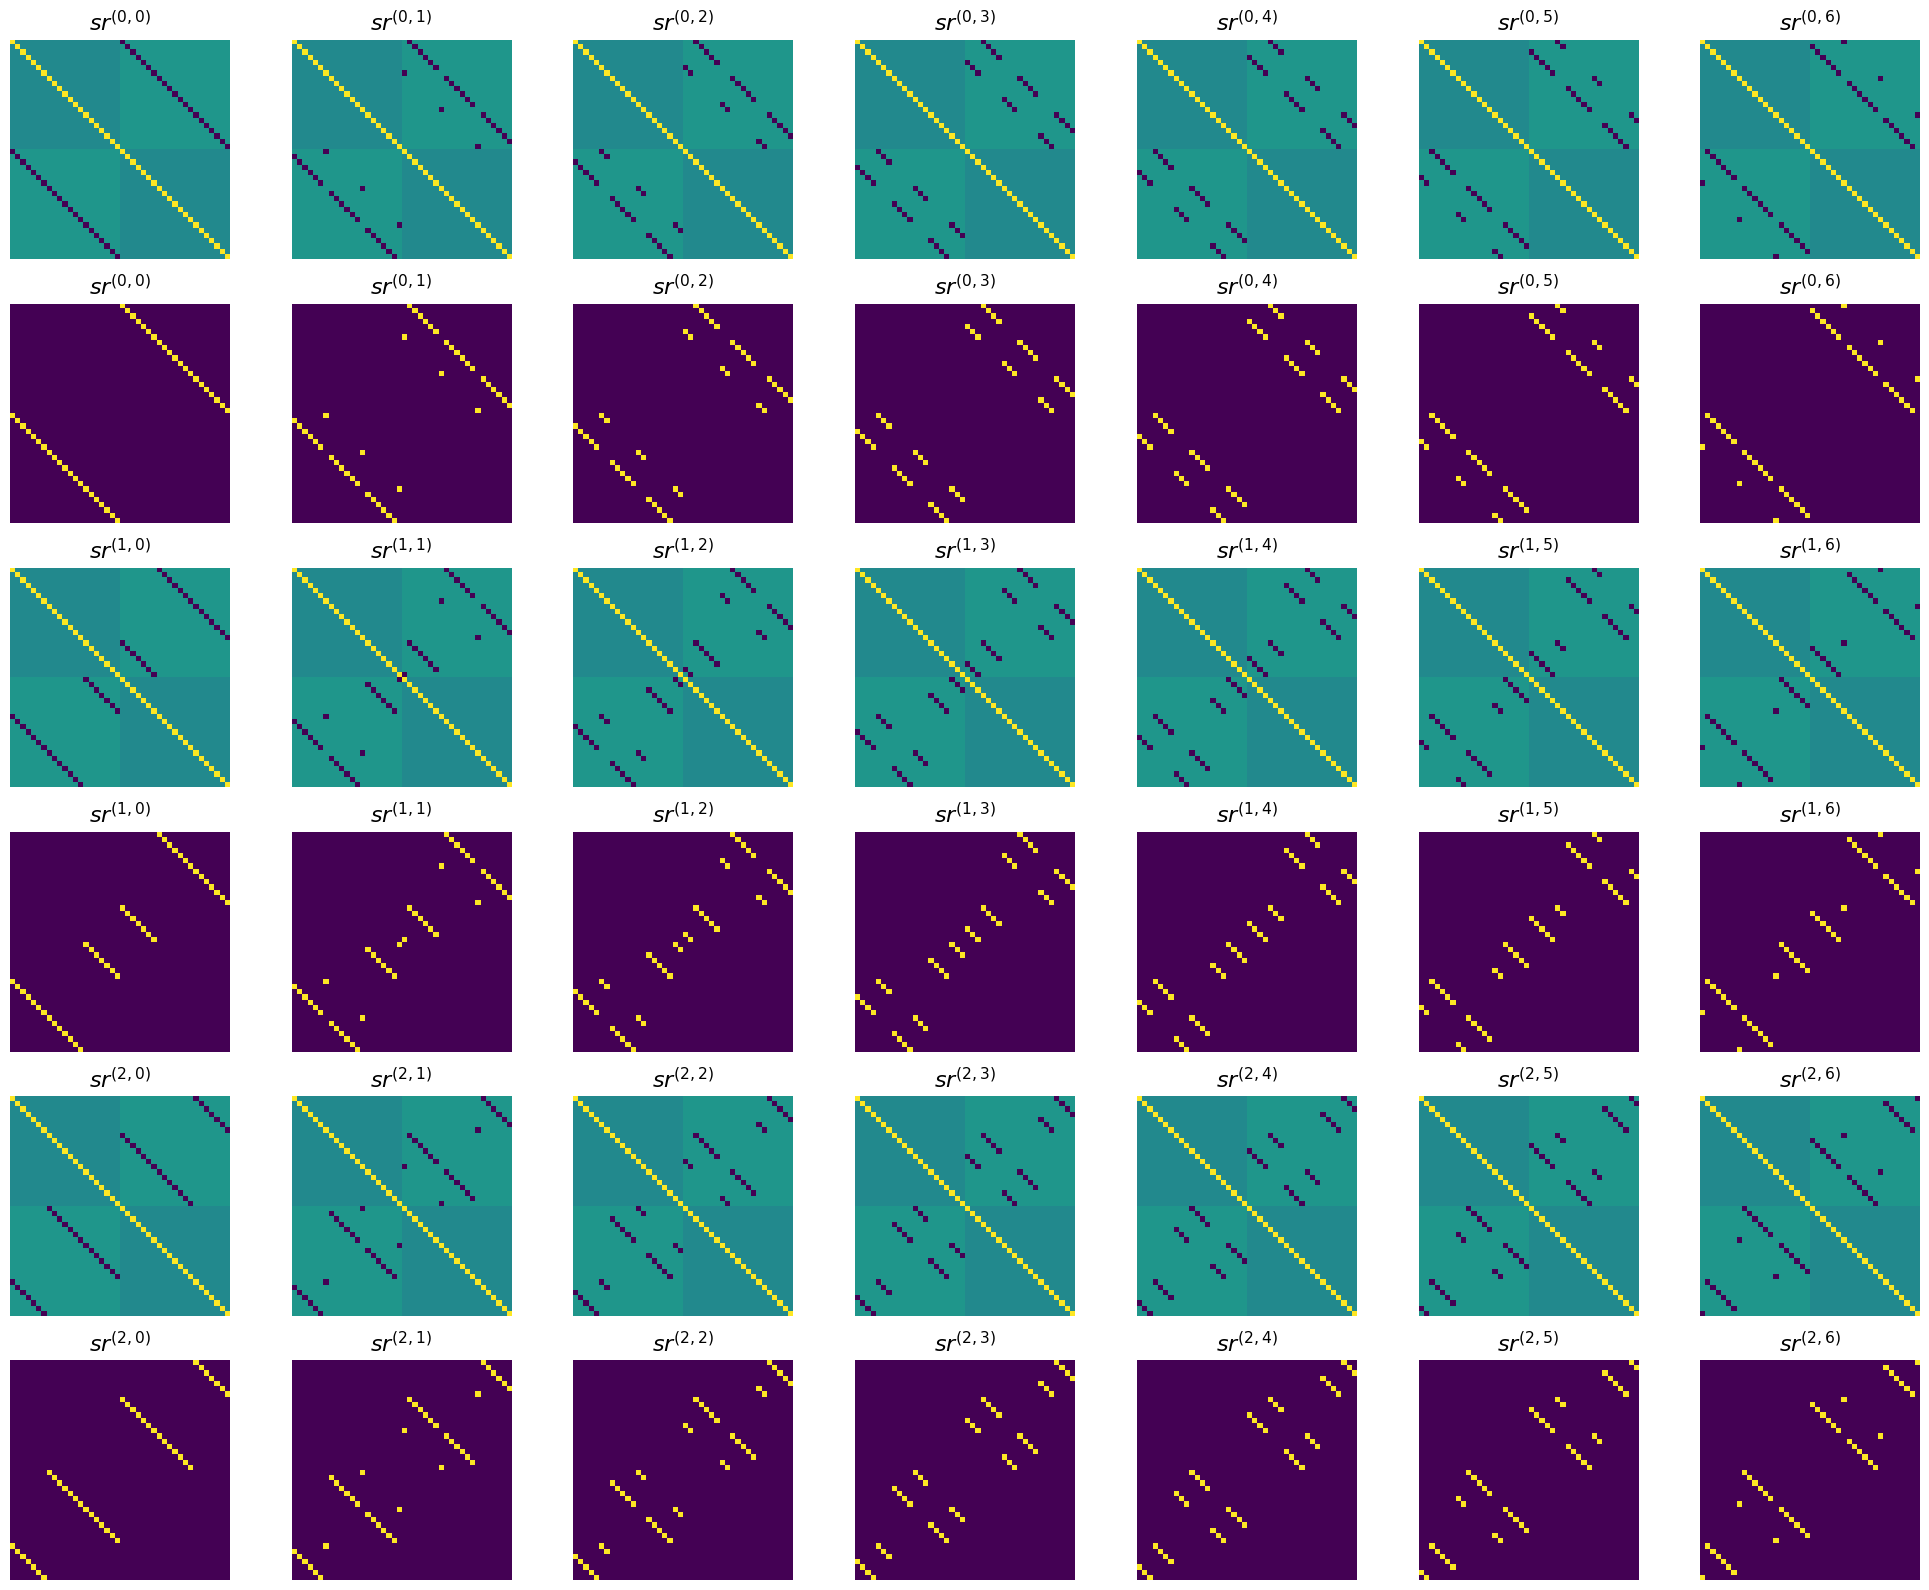

In [77]:
n = len(refls)
fig, axes = plt.subplots(6, 7, figsize=(20, 16))

for i in range(n):
    row_base = (i // 7) * 2
    col = i % 7

    # Plot agops[i]
    ax1 = axes[row_base][col]
    ax1.imshow(agops[i], cmap='viridis')
    ax1.set_title(f"$sr^{{{tuple(refls[i])}}}$", fontsize=16)
    ax1.axis('off')

    # Plot reps[('s', refls[i])]
    ax2 = axes[row_base + 1][col]
    rep_data = reps[('s', tuple(refls[i]))]
    ax2.imshow(rep_data, cmap='viridis')
    ax2.set_title(f"$sr^{{{tuple(refls[i])}}}$", fontsize=16)
    ax2.axis('off')

plt.tight_layout()
plt.show()

We can check how the test accuracy on all of these partitions is 0%.

In [80]:
import pandas as pd
acc_df = pd.DataFrame({
    'Reflection': [tuple(x) for x in refls],
    'Train Accuracy': [x.item() for x in tr_acc],
    'Test Accuracy': [x.item() for x in te_acc]
})

print(acc_df.to_string(index=False))

Reflection  Train Accuracy  Test Accuracy
    (0, 0)             1.0            0.0
    (0, 1)             1.0            0.0
    (0, 2)             1.0            0.0
    (0, 3)             1.0            0.0
    (0, 4)             1.0            0.0
    (0, 5)             1.0            0.0
    (0, 6)             1.0            0.0
    (1, 0)             1.0            0.0
    (1, 1)             1.0            0.0
    (1, 2)             1.0            0.0
    (1, 3)             1.0            0.0
    (1, 4)             1.0            0.0
    (1, 5)             1.0            0.0
    (1, 6)             1.0            0.0
    (2, 0)             1.0            0.0
    (2, 1)             1.0            0.0
    (2, 2)             1.0            0.0
    (2, 3)             1.0            0.0
    (2, 4)             1.0            0.0
    (2, 5)             1.0            0.0
    (2, 6)             1.0            0.0


Other dihedral subgroups (Section D.3). For addition modulo 32, elements $s$ and $r^{16}$  generate a dihedral subgroup of order 4, and  $s$ and $r^8$ generate a dihedral subgroup of order 8.

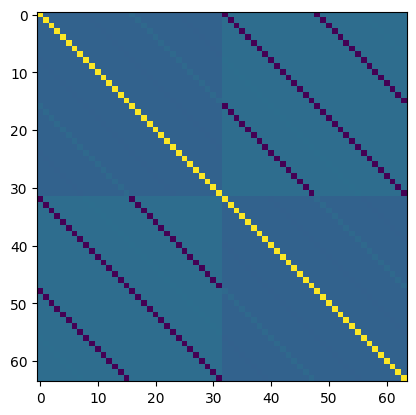

In [86]:
rfm_args.iters = 50
data_args.operation = 'x+y'
data_args.prime = 32
rfm_args.kernel_type = 'gaussian'
data_args.reflections = [0, 16]
results, _ = train(data_args, rfm_args)
plt.imshow(results.M_list[-1].cpu())

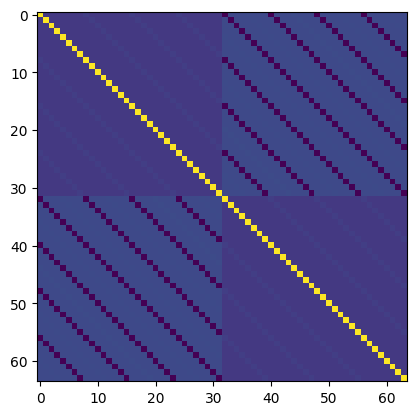

In [87]:
rfm_args.iters = 50
data_args.operation = 'x+y'
data_args.prime = 32
rfm_args.kernel_type = 'gaussian'
data_args.reflections = [0, 8, 16, 24]
results, _ = train(data_args, rfm_args)
plt.imshow(results.M_list[-1].cpu())

## Feature matrices and generalization

Experiments corresponding to Section 4 and Appendix F.

We train RFM with a Gaussian kernel on the abelian group $\mathcal{A}\cong \mathbb{Z}_5 \times \mathbb{Z}_7$ on 50% of the data, setting $M_0$ to be the feature matrix learned by RFM when trained on all the data except the fixed points under reflection $sr^{(2,3)}$.

In [89]:
data_args.operation = 'abelian'
data_args.prime = [5,7]
data_args.partition_type = 'random'
data_args.training_fraction = 0.5
data_args.M_reflection = [2,3]

In [90]:
results, rfm_args = train(data_args, rfm_args)

We separate the correct and incorrect predictions on the test set

In [91]:
preds = results.predictions.cpu()
y_te = rfm_args.y_te
X_te = rfm_args.X_te
X_tr = rfm_args.X_tr

X_te_correct, X_te_incorrect = split_predictions(preds, y_te, X_te)

We compute the orbit of the train set under the action of the subgroup generated by $sr^{(2,3)}$.

In [92]:
G = [('s', [2,3])]
X_preds = theoretical_predictions(rfm_args.X_tr, G, [5,7], 'abelian')

We compare such orbit to the actual correct predictions of RFM.

In [93]:
recall, precision = compare_theory(X_te_correct, X_preds)
print(f"Recall: {recall}, Precision: {precision}")

Recall: 1.0, Precision: 1.0


We visualize the results. The points marked in black are fixed points under $sr^{(2,3)}$, and thus they are either in the train set (gray) or incorrectly classified (red). The samples correctly classified are highlighted in blue.

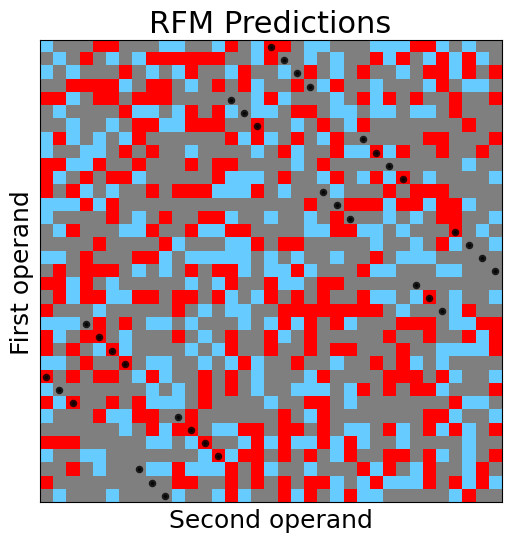

In [94]:
_ = visualize_ab_grid(X_tr, X_te_correct, X_te_incorrect, [2,3], 'abelian', group_sizes = [5,7])

In [ ]:
data_args.operation = 'x+y'
data_args.prime = 29
data_args.partition_type = 'random'
data_args.training_fraction = 0.5

grids = []
recalls = []
precisions = []
for i in range(29):
    data_args.M_reflection = i
    results, rfm_args = train(data_args, rfm_args)

    preds = results.predictions.cpu()
    y_te = rfm_args.y_te
    X_te = rfm_args.X_te
    X_tr = rfm_args.X_tr

    X_te_correct, X_te_incorrect = split_predictions(preds, y_te, X_te)

    G = [('s', i)]
    X_preds = theoretical_predictions(rfm_args.X_tr, G, 29, 'x+y')
    
    recall, precision = compare_theory(X_te_correct, X_preds)
    recalls.append(recall)
    precisions.append(precision)
    
    grids.append(visualize_ab_grid(X_tr, X_te_correct, X_te_incorrect, reflection_axis = i, operation = 'x+y'))

We show a full set of predictions for all reflections $sr^k$ for addition modulo 29. The reflection axis is marked in black. 
- Points in the reflection axis are either in the train set (gray) or incorrectly classified (red). 
- Incorrectly classified samples (red) are symmetric with respect to the reflection axis: if (a, b) is incorrectly classified, so is (b - k, a + k). 
- Correctly classified samples (blue) are in the orbit of the train set: if (a, b) is in the train set, (b - k, a + k) will be correctly classified.

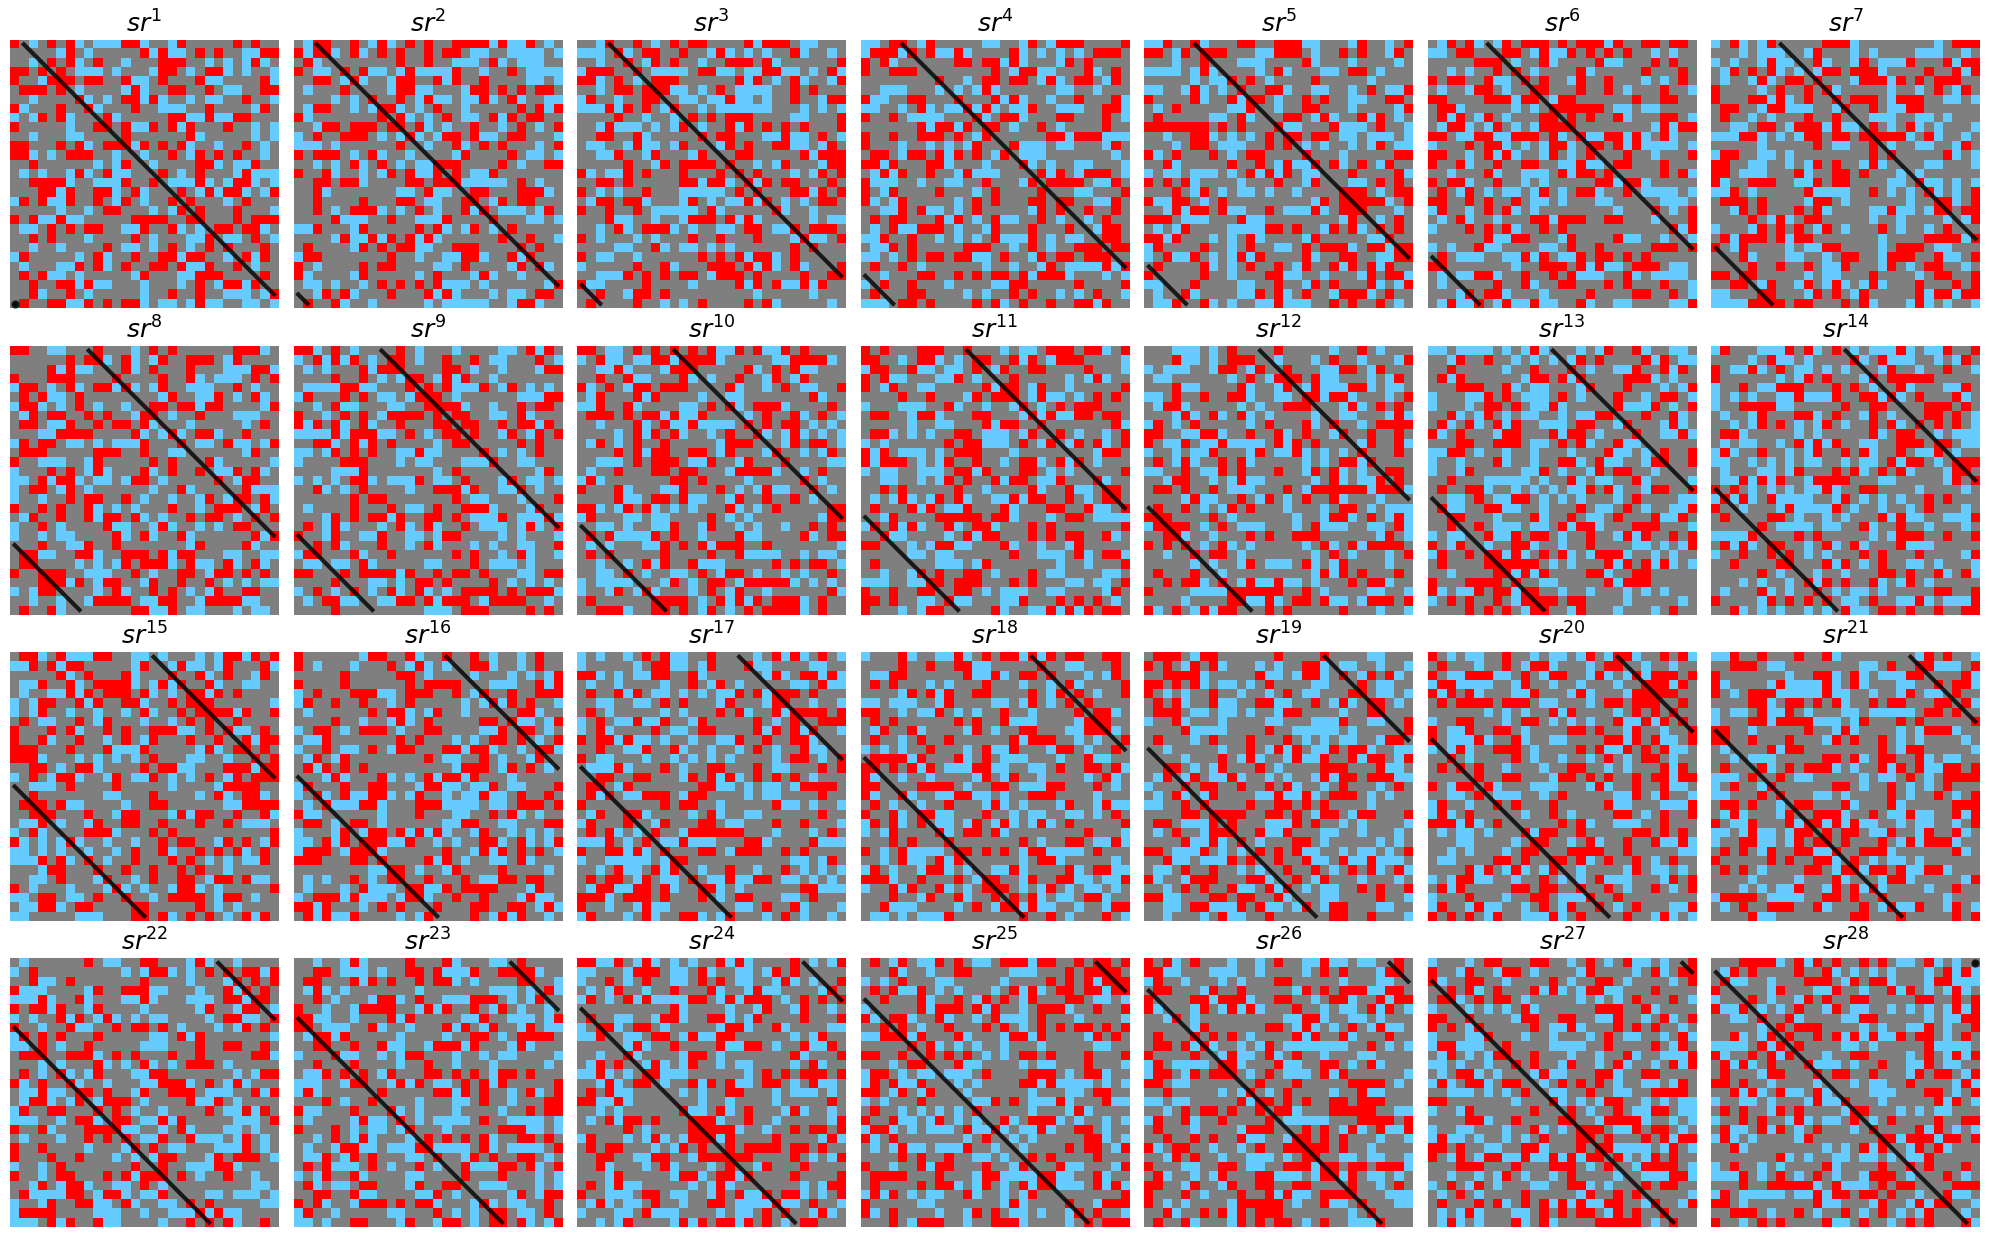

In [103]:
fig, axes = plt.subplots(nrows=4, ncols=7, figsize=(20, 12.5))

for i, ax in enumerate(axes.flat):
    if i > len(grids)-1:
        ax.axis('off')
    else:
        im = ax.imshow(grids[i+1], cmap='viridis')
        ax.set_title(r"$sr^{%s}$" % (i+1),fontsize=18)
        ax.axis('off')
        ax.grid(False)
        plot_cyclic_diagonal(ax, 29, k=(i+1), color='black', linewidth=3, alpha=0.8)

plt.tight_layout()
plt.show()

We check the precision and recall on all of these partitions:

In [101]:
for i in range(29):
    print(f"Reflection: sr^{i} -> Recall: {recalls[i]}, Precision: {precisions[i]}")

Reflection: sr^0 -> Recall: 1.0, Precision: 1.0
Reflection: sr^1 -> Recall: 1.0, Precision: 1.0
Reflection: sr^2 -> Recall: 1.0, Precision: 1.0
Reflection: sr^3 -> Recall: 1.0, Precision: 1.0
Reflection: sr^4 -> Recall: 1.0, Precision: 1.0
Reflection: sr^5 -> Recall: 1.0, Precision: 1.0
Reflection: sr^6 -> Recall: 1.0, Precision: 1.0
Reflection: sr^7 -> Recall: 1.0, Precision: 1.0
Reflection: sr^8 -> Recall: 1.0, Precision: 1.0
Reflection: sr^9 -> Recall: 1.0, Precision: 1.0
Reflection: sr^10 -> Recall: 1.0, Precision: 1.0
Reflection: sr^11 -> Recall: 1.0, Precision: 1.0
Reflection: sr^12 -> Recall: 1.0, Precision: 1.0
Reflection: sr^13 -> Recall: 1.0, Precision: 1.0
Reflection: sr^14 -> Recall: 1.0, Precision: 1.0
Reflection: sr^15 -> Recall: 1.0, Precision: 1.0
Reflection: sr^16 -> Recall: 1.0, Precision: 1.0
Reflection: sr^17 -> Recall: 1.0, Precision: 1.0
Reflection: sr^18 -> Recall: 1.0, Precision: 1.0
Reflection: sr^19 -> Recall: 1.0, Precision: 1.0
Reflection: sr^20 -> Recall: 1